# **Random Forest Modeling**

**Purpose**
- Train and evaluate the XGBoost model for dengue risk classification.

**Dataset**
- Cleaned CALABARZON dengue dataset with climate, socioeconomic, and environmental variables.

**Process**
- Load the prepared dataset.
- Define feature groups and target variable.
- Train the XGBoost classification model.
- Evaluate model performance across feature sets.

**Output**
- Model performance results for the Ranfom Forest model.

In [1]:
# =============================
# Import Libraries
# =============================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier

In [2]:
# =============================
# Load Dataset
# =============================
DATA_PATH = "/Users/alexandrasantos/Downloads/Thesis_Dataset_Processed (Final).xlsx"
df = pd.read_excel(DATA_PATH)

Full Model (Climate)
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 5)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7552
Best params: {'n_estimators': 800, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 'sqrt', 'max_depth': 10, 'class_weight': None, 'bootstrap': True}

Hold-out accuracy: 0.761

Classification report:
              precision    recall  f1-score   support

        High     0.5714    0.0816    0.1429        98
         Low     0.8134    0.9324    0.8688      1183
      Medium     0.5258    0.4026    0.4560       380

    accuracy                         0.7610      1661
   macro avg     0.6369    0.4722    0.4892      1661
weighted avg     0.7333    0.7610    0.7316      1661



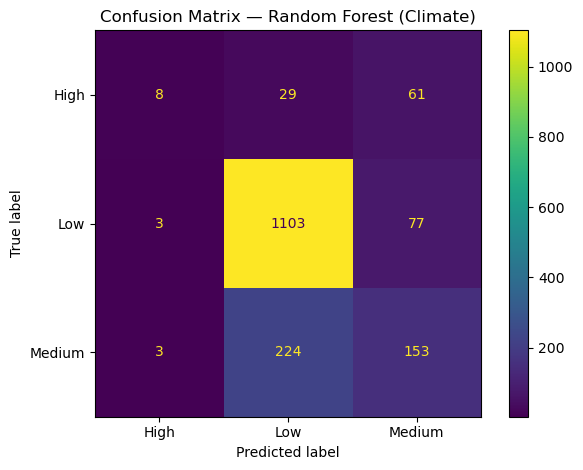

In [3]:
# ============================================================
# FULL MODEL: Climate 
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]
TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]
# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + time)
numeric_cols = [
    "Rain", "Temperature", "Relative Humidity",
    "Month", "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model (Climate)")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Random Forest + Hyperparameter Tuning
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None]   # you said no class weighting
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Random Forest (Climate)")
plt.tight_layout()
plt.show()

Full Model (Socioeconomic) — Random Forest
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 14)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7936
Best params: {'n_estimators': 1200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': None, 'bootstrap': False}

Hold-out accuracy: 0.8025

Classification report:
              precision    recall  f1-score   support

        High     0.6667    0.4082    0.5063        98
         Low     0.8533    0.9391    0.8942      1183
      Medium     0.6087    0.4789    0.5361       380

    accuracy                         0.8025      1661
   macro avg     0.7096    0.6087    0.6455      1661
weighted avg     0.7863    0.8025    0.7894      1661



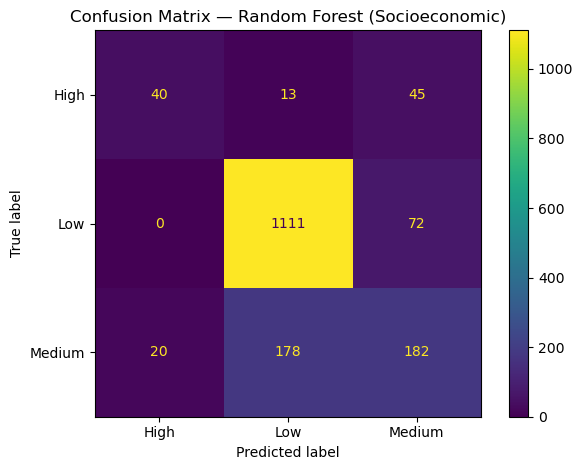

In [4]:
# ============================================================
# FULL MODEL: Socioeconomic
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + SOCIO_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[SOCIO_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (socio numeric + time)
numeric_cols = [
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical socio columns
cat_cols = ["Municipal Class", "Settlement Type"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model (Socioeconomic) — Random Forest")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Random Forest + Hyperparameter Tuning
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Random Forest (Socioeconomic)")
plt.tight_layout()
plt.show()

Full Model (Environmental) — Random Forest
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 11)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7971
Best params: {'n_estimators': 1200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'class_weight': None, 'bootstrap': False}

Hold-out accuracy: 0.8092

Classification report:
              precision    recall  f1-score   support

        High     0.6000    0.4592    0.5202        98
         Low     0.8691    0.9315    0.8992      1183
      Medium     0.6195    0.5184    0.5645       380

    accuracy                         0.8092      1661
   macro avg     0.6962    0.6364    0.6613      1661
weighted avg     0.7961    0.8092    0.8003      1661



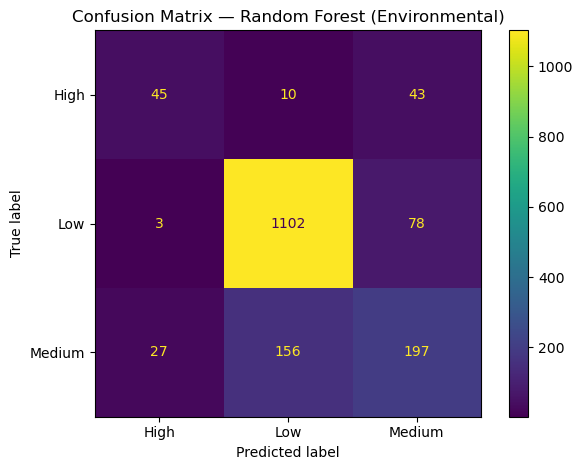

In [5]:
# ============================================================
# FULL MODEL: Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (env numeric + time)
numeric_cols = [
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical environmental columns
cat_cols = ["Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model (Environmental) — Random Forest")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Random Forest + Hyperparameter Tuning
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Random Forest (Environmental)")
plt.tight_layout()
plt.show()

Full Model (Climate + Socioeconomic) — Random Forest
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 17)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7768
Best params: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': None, 'bootstrap': False}

Hold-out accuracy: 0.7784

Classification report:
              precision    recall  f1-score   support

        High     0.6190    0.2653    0.3714        98
         Low     0.8219    0.9400    0.8770      1183
      Medium     0.5827    0.4079    0.4799       380

    accuracy                         0.7784      1661
   macro avg     0.6745    0.5377    0.5761      1661
weighted avg     0.7552    0.7784    0.7563      1661



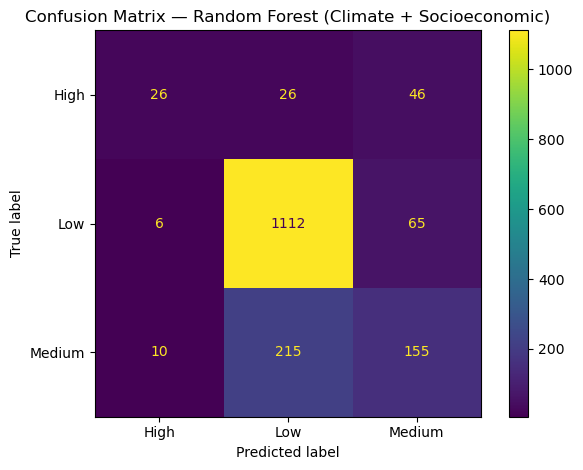

In [6]:
# ============================================================
# FULL MODEL: Climate + Socioeconomic
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + SOCIO_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + SOCIO_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + socio numeric + time)
numeric_cols = [
    # climate
    "Rain", "Temperature", "Relative Humidity",
    # socio numeric
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    # time
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical socio columns
cat_cols = ["Municipal Class", "Settlement Type"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model (Climate + Socioeconomic) — Random Forest")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Random Forest + Hyperparameter Tuning
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Random Forest (Climate + Socioeconomic)")
plt.tight_layout()
plt.show()

Full Model (Climate + Environmental) — Random Forest
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 14)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7861
Best params: {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 30, 'class_weight': None, 'bootstrap': False}

Hold-out accuracy: 0.7929

Classification report:
              precision    recall  f1-score   support

        High     0.6111    0.3367    0.4342        98
         Low     0.8445    0.9366    0.8882      1183
      Medium     0.5966    0.4632    0.5215       380

    accuracy                         0.7929      1661
   macro avg     0.6841    0.5788    0.6146      1661
weighted avg     0.7740    0.7929    0.7775      1661



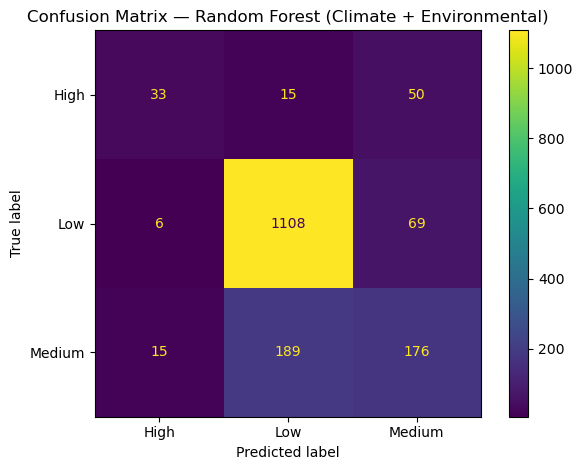

In [7]:
# ============================================================
# FULL MODEL: Climate + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + env numeric + time)
numeric_cols = [
    # climate
    "Rain", "Temperature", "Relative Humidity",
    # env numeric
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    # time
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical environmental columns
cat_cols = ["Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model (Climate + Environmental) — Random Forest")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Random Forest + Hyperparameter Tuning
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Random Forest (Climate + Environmental)")
plt.tight_layout()
plt.show()

Full Model (Socioeconomic + Environmental) — Random Forest
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 23)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7939
Best params: {'n_estimators': 800, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': None, 'class_weight': None, 'bootstrap': True}

Hold-out accuracy: 0.8031

Classification report:
              precision    recall  f1-score   support

        High     0.6081    0.4592    0.5233        98
         Low     0.8695    0.9180    0.8931      1183
      Medium     0.6006    0.5342    0.5655       380

    accuracy                         0.8031      1661
   macro avg     0.6927    0.6371    0.6606      1661
weighted avg     0.7926    0.8031    0.7963      1661



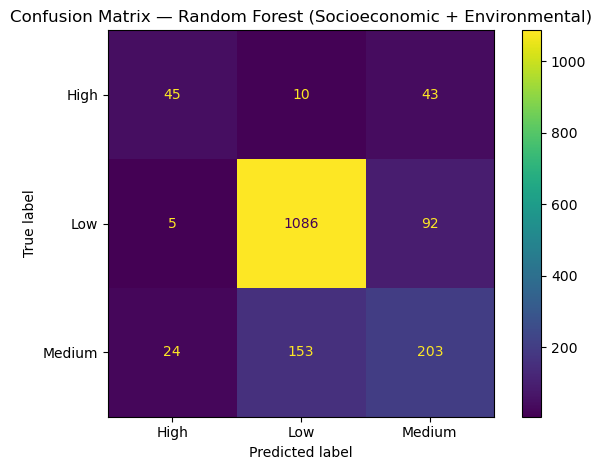

In [8]:
# ============================================================
# FULL MODEL: Socioeconomic + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + SOCIO_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[SOCIO_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (socio numeric + env numeric + time)
numeric_cols = [
    # socio numeric
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    # env numeric
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    # time
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model (Socioeconomic + Environmental) — Random Forest")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Random Forest + Hyperparameter Tuning
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Random Forest (Socioeconomic + Environmental)")
plt.tight_layout()
plt.show()

Full Model (Climate + Socioeconomic + Environmental) — Random Forest
Classes: ['High', 'Low', 'Medium']
X shape: (8304, 26)
Fitting 5 folds for each of 120 candidates, totalling 600 fits

Best CV accuracy: 0.7906
Best params: {'n_estimators': 1200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': None, 'max_depth': 15, 'class_weight': None, 'bootstrap': True}

Hold-out accuracy: 0.7971

Classification report:
              precision    recall  f1-score   support

        High     0.6545    0.3673    0.4706        98
         Low     0.8515    0.9307    0.8893      1183
      Medium     0.5974    0.4921    0.5397       380

    accuracy                         0.7971      1661
   macro avg     0.7012    0.5967    0.6332      1661
weighted avg     0.7818    0.7971    0.7846      1661



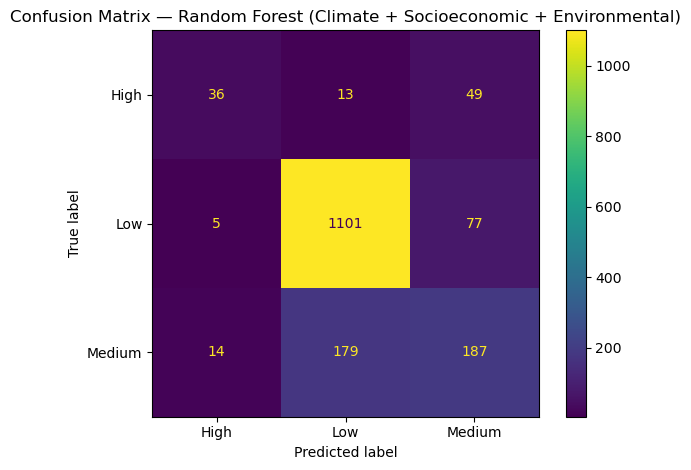

In [9]:
# ============================================================
# FULL MODEL: Climate + Socioeconomic + Environmental
# ============================================================

# -----------------------------
# Columns
# -----------------------------
TARGET_COL = "Dengue Risk Level"

CLIMATE_COLS = ["Rain", "Temperature", "Relative Humidity"]

SOCIO_COLS = [
    "Municipal Class",
    "Total Population",
    "Settlement Type",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
]

ENV_COLS = [
    "Flood Hazard Level",
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
]

TIME_COLS = ["Month", "Year"]

LEAKAGE_COLS = ["Dengue Cases", "Death Cases", "Dengue Incidence"]

# -----------------------------
# Validate
# -----------------------------
required = [TARGET_COL] + CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing columns: {missing}")

# Drop leakage columns
df = df.drop(columns=[c for c in LEAKAGE_COLS if c in df.columns], errors="ignore")

# Remove rows with no label or time
df = df.dropna(subset=[TARGET_COL, "Month", "Year"]).copy()

# Convert Month/Year properly
df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
df["Year"]  = pd.to_numeric(df["Year"], errors="coerce")
df = df.dropna(subset=["Month", "Year"])

df["Month"] = df["Month"].astype(int)
df["Year"]  = df["Year"].astype(int)

# -----------------------------
# Build X and y
# -----------------------------
X = df[CLIMATE_COLS + SOCIO_COLS + ENV_COLS + TIME_COLS].copy()
y = df[TARGET_COL].astype(str)

# Numeric columns (climate + socio numeric + env numeric + time)
numeric_cols = [
    # climate
    "Rain", "Temperature", "Relative Humidity",
    # socio numeric
    "Total Population",
    "Public Healthcare Facilities",
    "Private Healthcare Facilities",
    # env numeric
    "Forest Cover (%)",
    "Agricultural Land (%)",
    "Water Bodies (%)",
    "Open Vegetation (%)",
    "Built-up / Barren (%)",
    # time
    "Month",
    "Year"
]

for c in numeric_cols:
    X[c] = pd.to_numeric(X[c], errors="coerce")

X[numeric_cols] = X[numeric_cols].fillna(X[numeric_cols].median())

# Categorical columns
cat_cols = ["Municipal Class", "Settlement Type", "Flood Hazard Level"]
for c in cat_cols:
    X[c] = X[c].astype(str).fillna("Unknown")

# One-hot encoding
X = pd.get_dummies(X, columns=cat_cols, drop_first=False)

# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
class_names = list(le.classes_)
num_classes = len(class_names)

print("Full Model (Climate + Socioeconomic + Environmental) — Random Forest")
print("Classes:", class_names)
print("X shape:", X.shape)

# -----------------------------
# Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    random_state=42,
    stratify=y_enc
)

# -----------------------------
# Random Forest + Hyperparameter Tuning
# -----------------------------
rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [300, 500, 800, 1200],
    "max_depth": [None, 5, 10, 15, 20, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
    "class_weight": [None]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=120,
    scoring="accuracy",
    cv=cv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_

print("\nBest CV accuracy:", round(search.best_score_, 4))
print("Best params:", search.best_params_)

# -----------------------------
# Evaluation
# -----------------------------
y_pred = best_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("\nHold-out accuracy:", round(acc, 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=class_names).plot(values_format="d")
plt.title("Confusion Matrix — Random Forest (Climate + Socioeconomic + Environmental)")
plt.tight_layout()
plt.show()